# Import


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
from plotly.offline import init_notebook_mode
from sklearn.model_selection import train_test_split

In [4]:
warnings.filterwarnings("ignore")
init_notebook_mode(connected=True)

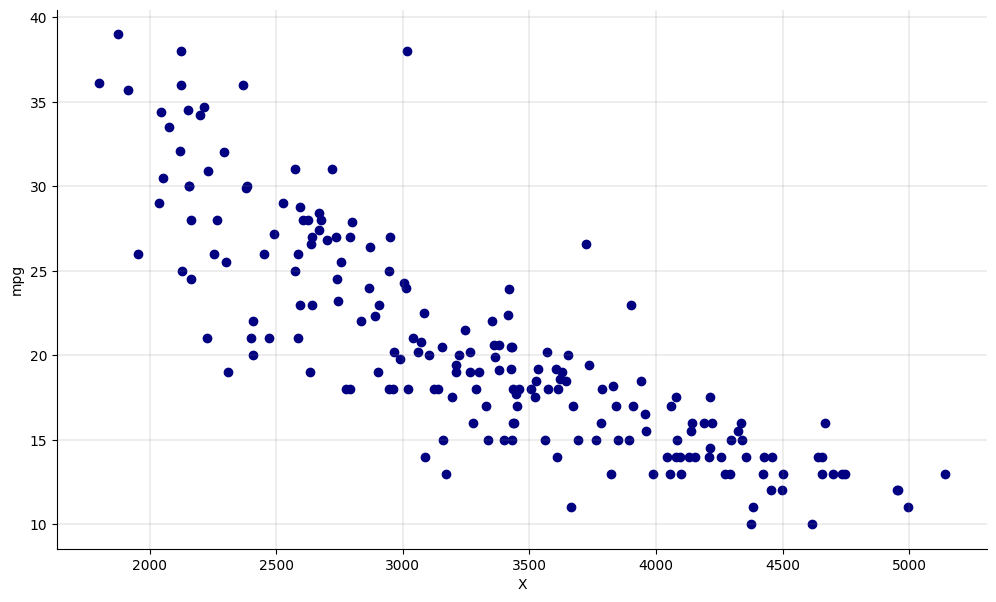

In [6]:
df = (
    pd.read_csv("mpg.csv")
    .query("origin == 'usa'")[["weight", "mpg"]]
    .rename(columns={"weight": "X", "mpg": "Y"})
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)


X = df["X"].values
Y = df["Y"].values

#split train & test sets
x_train, x_test, y_train, y_test = X_train, X_test,y_train, y_test = train_test_split(X,Y , 
                                   random_state=42,  
                                   test_size=0.2,  
                                   shuffle=True) 


fig, ax = plt.subplots(figsize=(12, 7))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.8)
ax.scatter(x_train, y_train, color="navy")
plt.xlabel('X')
plt.ylabel('mpg')
plt.show()

# Regression Func to Implement


In [7]:
p_Nth_array = []


def modelingFunction(x_train, y_train, x_test, y_test, deg):
    # use np to make  a polynomial regression model(ployfit) and then
    # use it on the train and test data (polyval)
    polynomial_Nthdeg_model = np.polyfit(x_train, y_train, deg)
    
    polynomial_Nthdeg_predictions = np.polyval(polynomial_Nthdeg_model, x_test)
    training_polynomial_Nthdeg_predictions = np.polyval(polynomial_Nthdeg_model, x_train)
    
    p_Nth = np.poly1d(polynomial_Nthdeg_model.reshape(1, deg + 1)[0])
    p_Nth_array.append(p_Nth)
    return polynomial_Nthdeg_predictions

# Testing metrics Func


In [8]:
degree = []
training_mse = []
test_mse = []
bias = []
variance = []

In [9]:
def bias_variance_bootstrap(x, y, degree, B=20000):
    preds = np.zeros((B, len(x)))
    for b in range(B):
        idx = np.random.choice(len(x), len(x), replace=True)
        model = np.poly1d(np.polyfit(x[idx], y[idx], degree))
        preds[b] = model(x)  # prediction on **full** data
    pred_mean = preds.mean(axis=0)
    bias_sq = np.mean((pred_mean - y) ** 2)
    var = np.mean(preds.var(axis=0))
    return bias_sq, var

In [10]:
def metricTestingFunction(
    x,
    y,
    Ndegree,
):

    b, v = bias_variance_bootstrap(x, y, Ndegree, B=200)
    bias.append(b)
    variance.append(v)
    degree.append(Ndegree)
    metricData = f"bias = {b} , var = {v}"
    return metricData

# Plot Function


In [11]:
def plotModels(deg, data):
    fig, ax = plt.subplots(figsize=(12, 7))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.1)
    polynomial_predictions = modelingFunction(x_train, y_train, x_test, y_test, deg)
    x_linspace = np.linspace(min(X), max(X), num=len(polynomial_predictions))
    main = ax.scatter(X, Y, color="grey", alpha=0.6, linewidth=6)

    plotReturn = plt.plot(
        x_linspace, p_Nth_array[-1](x_linspace), color="firebrick", linewidth=1
    )

    plt.legend(plotReturn[:1], [f"{deg}th Degree" + data])

bias = 7.376452166288824 , var = 0.38974264814672566
bias = 6.477793918377722 , var = 0.5995535174940801
bias = 6.5960684089018375 , var = 1.2467602779530584
bias = 5.813259480082537 , var = 1.6970084388652673
bias = 5.713633588336005 , var = 1.7040393007768129
bias = 5.9695187337223725 , var = 12.78046755747845


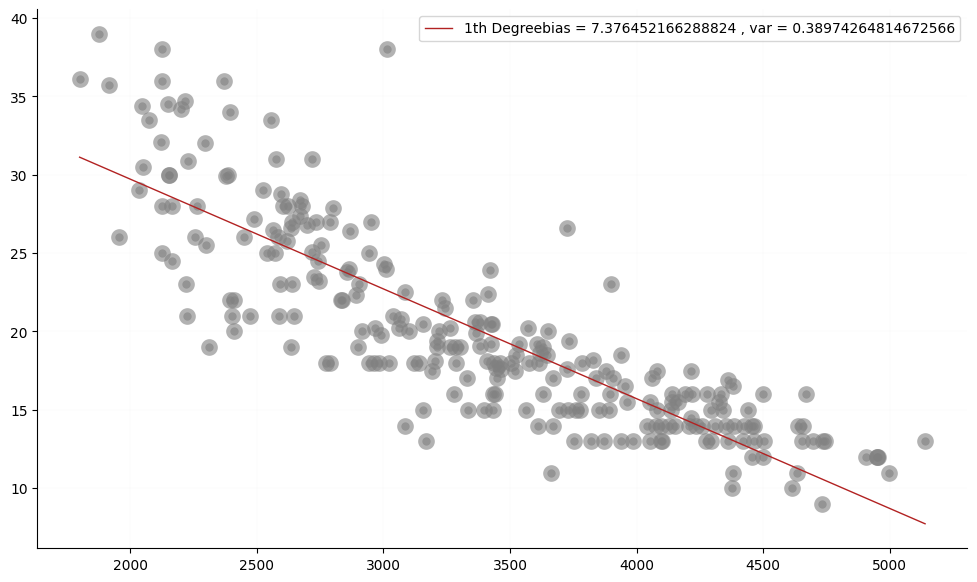

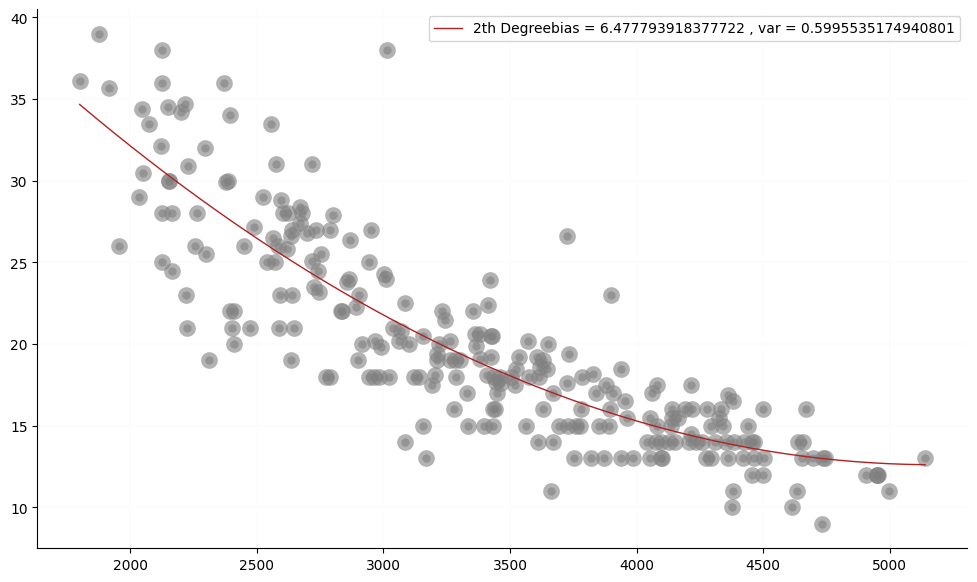

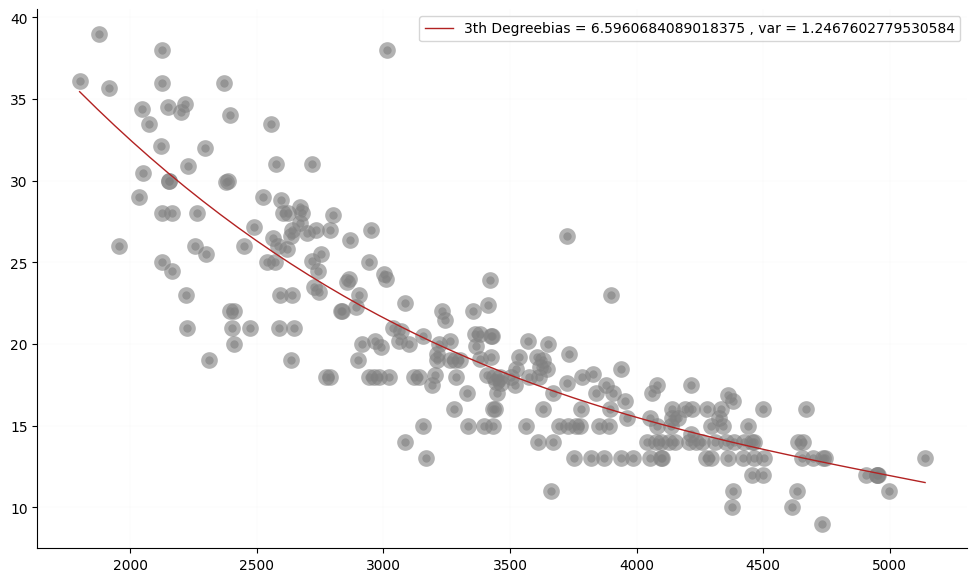

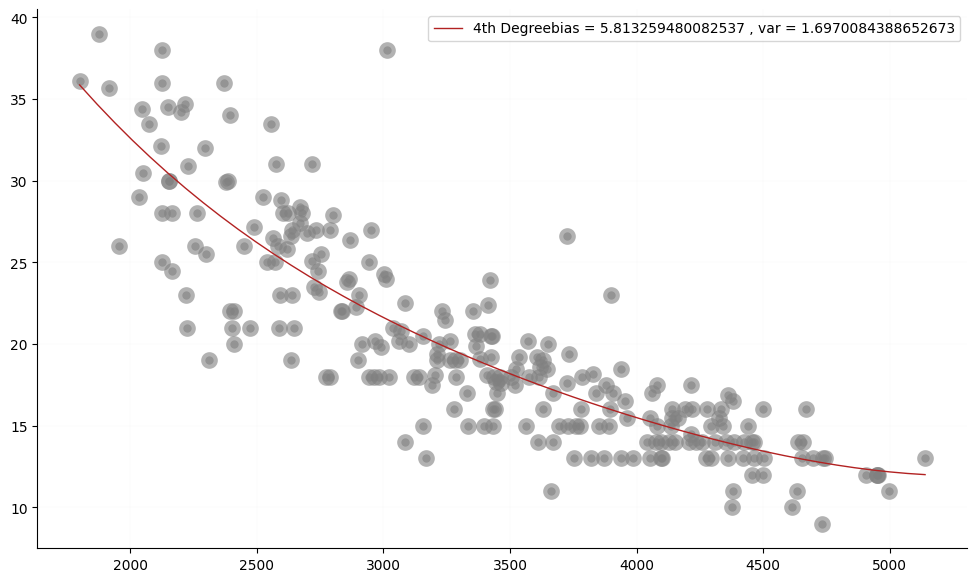

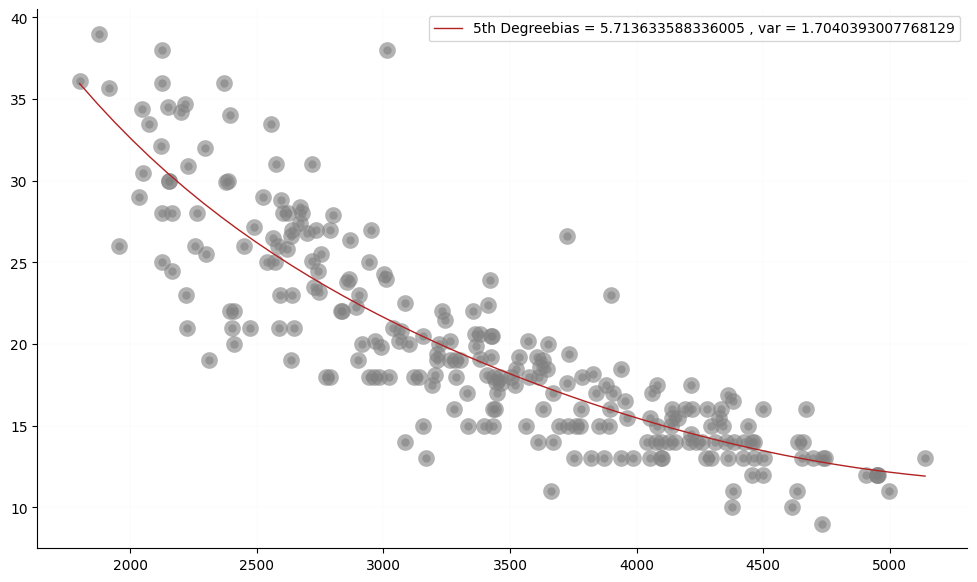

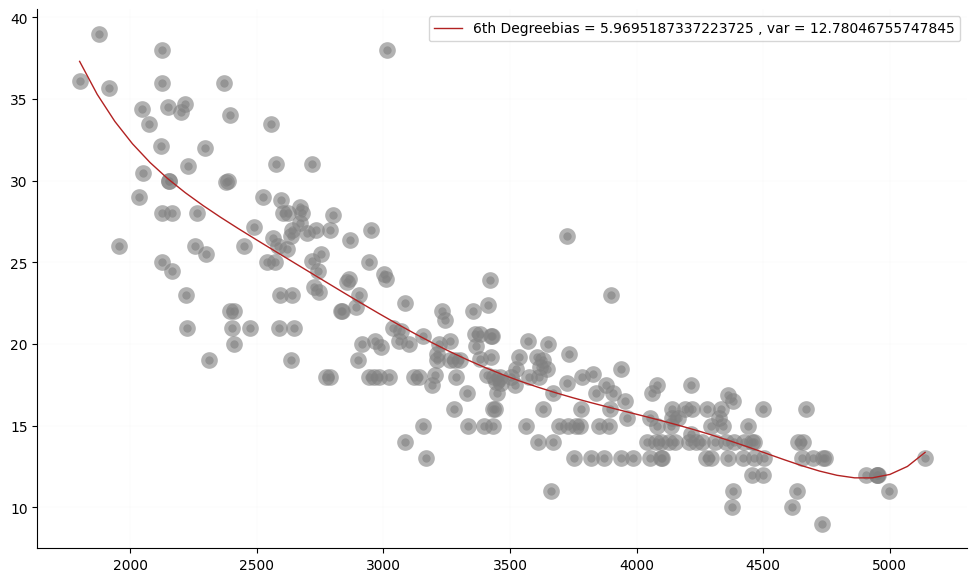

In [13]:
for deg in range(1, 7):

    # run the modeling function for each degree
    # then, get the metric data using metricTesting function
    modeling_pred = modelingFunction(x_train, y_train, x_test, y_test, deg)
    
    metricData = metricTestingFunction(x_test, y_test, deg)

    plotModels(deg, metricData)

    print(metricData)

# Questions


- بایاس و ورایانس را تعریف کنید. تغییرات این دو چه نسبتی با هم دارد؟

بایاس  به فاصله بین مقدار پیش‌بینی شده با مقدار واقعی اشاره دارد. در حالتی که بایاس زیاد است، به‌ احتمال زیاد، پیش‌بینی‌ها در یک مسیر دور از مقادیر واقعی، تغییر جهت داده است. واریانس  توصیف می‌کند که مقادیر پیش‌بینی شده چه میزان پراکنده هستند.


- کدام مدل بهترین عملکرد را دارد ؟چرا؟
با توجه به مقادیر بدست آمده برای واریانس و بایاس مدل های درجه 2 و 3 با توجه به شکل داده های ورودی بهترین عملکرد را دارند
اما بهترین بظرم درجه 2 عه چون کمترین بایاس و واریانس رو داره


در ادامه به داده های تست مقداری نویز وارد میکنیم
قطعه کد های زیر را وارد کرده و به سوالات جواب دهید


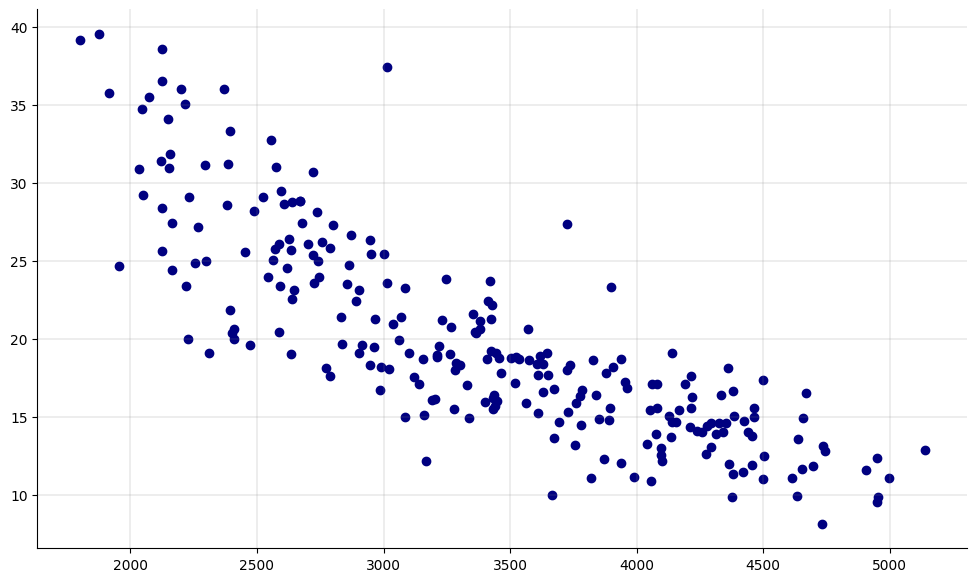

In [16]:
noise_std_x = 0.5  # Adjust this to control noise strength
x_train_noisy = X + np.random.normal(loc=0, scale=noise_std_x, size=X.shape)

noise_std_y = 0.1 * np.std(Y)  # Noise proportional to Y's variability
y_train_noisy = Y + np.random.normal(loc=0, scale=noise_std_y, size=Y.shape)


X = x_train_noisy
Y = y_train_noisy
#split train & test sets
x_train, x_test, y_train, y_test = train_test_split(X,Y , 
                                   random_state=42,  
                                   test_size=0.2,  
                                   shuffle=True) 

fig, ax = plt.subplots(figsize=(12, 7))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.8)
ax.scatter(X, Y, color="navy")
plt.show()

bias = 8.098333831208572 , var = 0.3940185764918283
bias = 7.362140933957028 , var = 0.5902332503019369
bias = 7.260780300920279 , var = 1.1534974136854312
bias = 6.420854412294326 , var = 1.6014719039751582
bias = 6.329223851245463 , var = 3.872323353384881
bias = 6.971613329387746 , var = 15.736643621749764


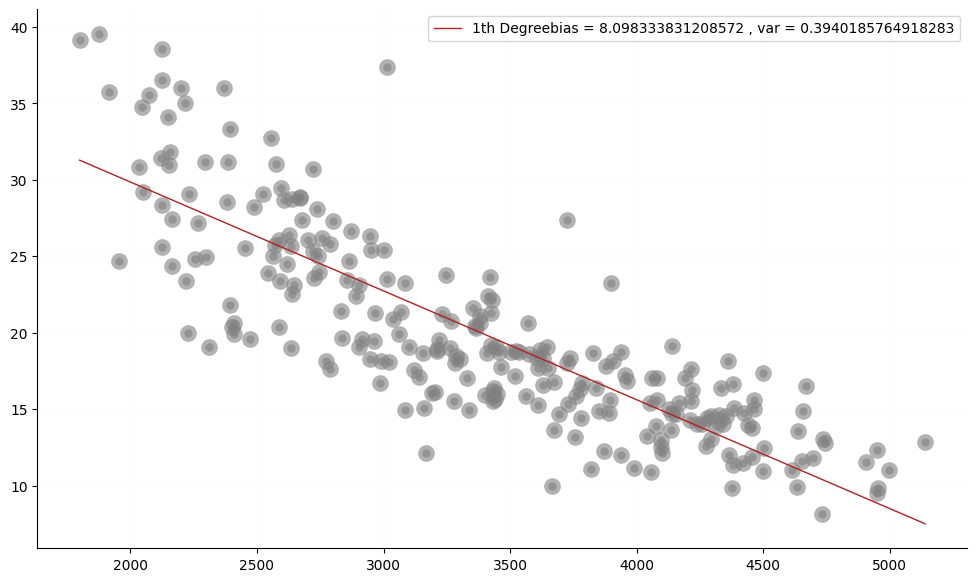

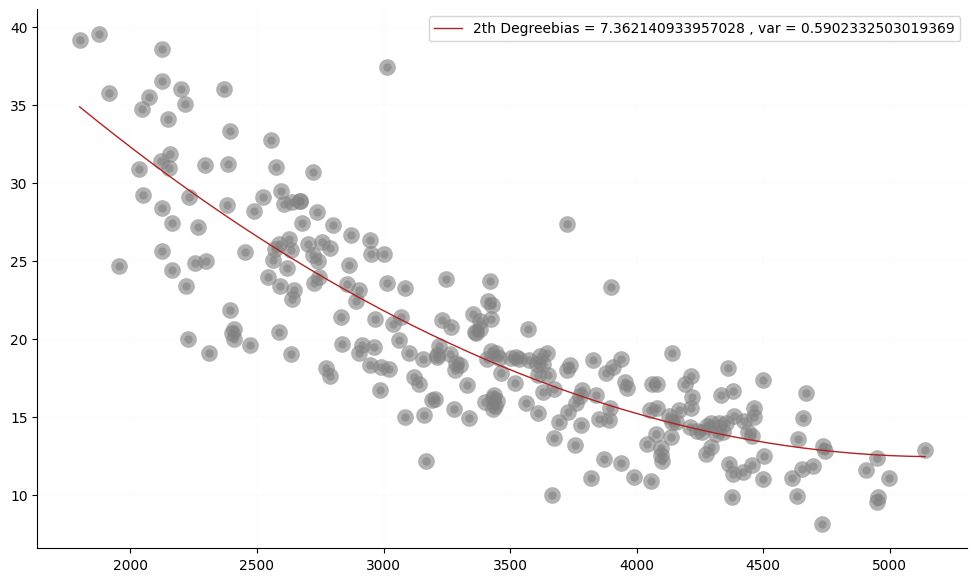

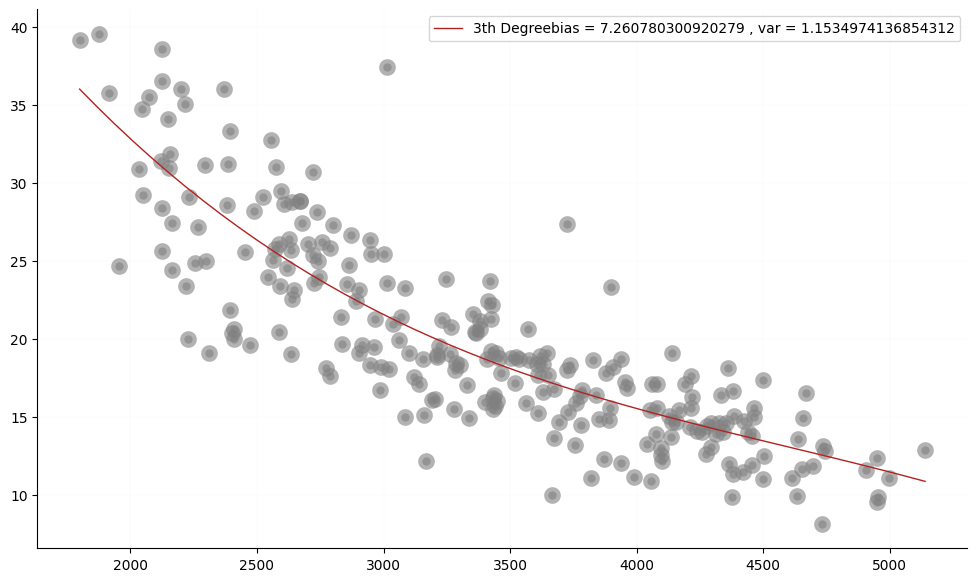

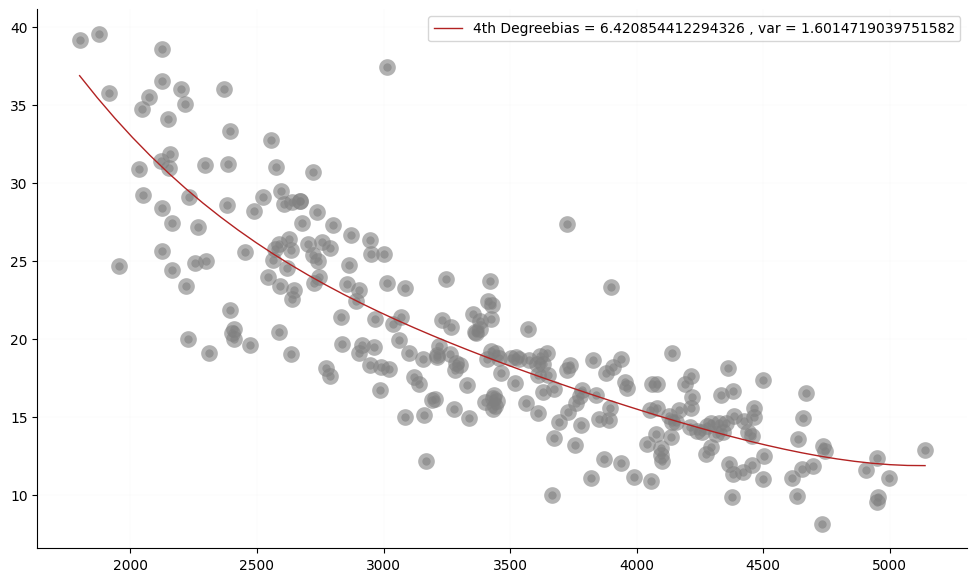

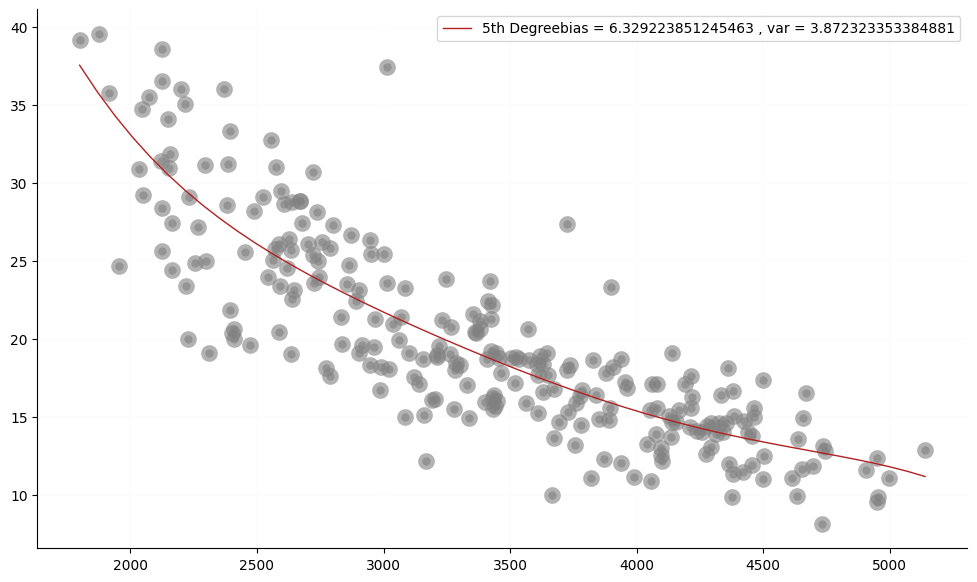

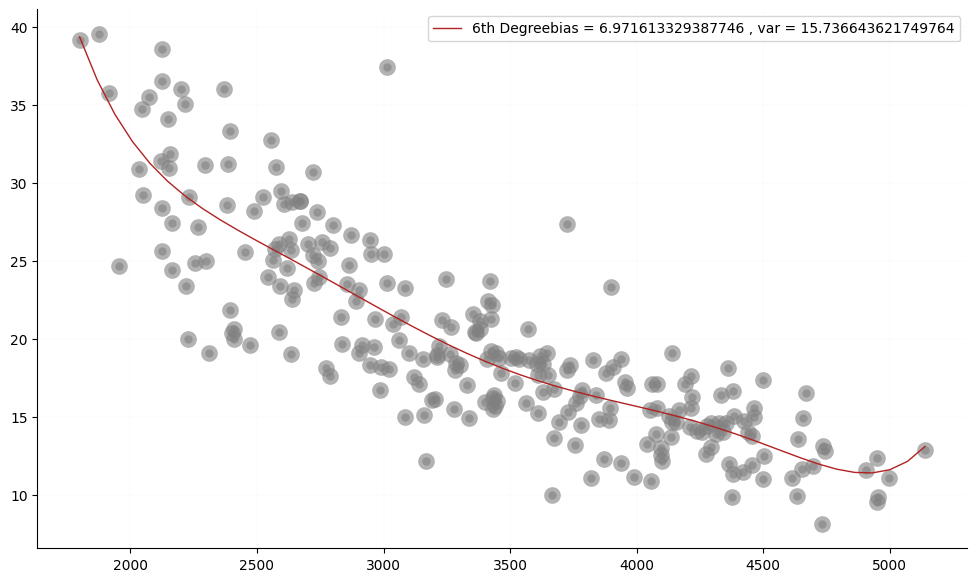

In [17]:
for deg in range(1, 7):

    # run the modeling function for each degree
    # then, get the metric data using metricTesting function

    modeling_pred = modelingFunction(x_train, y_train, x_test, y_test, deg)
    
    metricData = metricTestingFunction(x_test, y_test, deg)
    plotModels(deg, metricData)

    print(metricData)

- نویز داشته داده های اولیه چه تاثیری بر مدل ها و بایاس و واریانس آن ها داشته است و چرا ؟

اضافه کردن نویز باعث کاهش واریانس و افزایش بایاس شده است. دلیل این هم اینه
چون نویز باعث شد که مدلمون نتونه الگوی واقعی رو درست یاد بگیره و همچنین مدل ها چون نتونستن نویز رو درست دنبال کنن بخاطر همین واریانس اونا کاهش پیدا کرده


# پایان

خسته نباشید
